# Coffee Grind Adjustments

Recommend the next espresso shot's dose and grinder setting from the last shot's dose, grinder temperature and
shot time.

Grinder settings are written `major+minor`, e.g. `7+6.5` is major tick 7 plus 6.5 of the 10 minor ticks, i.e. 7.65
major ticks. A linear model converts deviations from the ideal shot into a setting change:

$$\Delta\text{setting} = a\,\Delta T + b\,\Delta t + c\,\Delta D$$

Rules, in order:
1. If the dose is outside its tolerance, reset it to the ideal dose and fold that change into the setting.
2. If time and temperature are both close to ideal, leave the grinder alone and nudge the dose instead.
3. Otherwise change the grinder setting.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np

# Ideal shot
IDEAL_DOSE = 20  # g
IDEAL_TEMP = 66  # F (grinder temperature)
IDEAL_TIME = 28  # s
MINOR_TICKS_PER_MAJOR = 10

# Tolerances
LOW_DOSE = 19     # g
HIGH_DOSE = 20.1  # g
TIME_TOLERANCE = 4  # s
TEMP_TOLERANCE = 2  # F

# Model coefficients (major ticks per unit)
A_TEMP = 1 / 60   # per degree F
B_TIME = -1 / 85  # per second (probably nonlinear?)
C_DOSE = 1 / 20   # per gram


def parse_setting(reading):
    """'7+6.5' -> 7.65 major ticks."""
    major, minor = reading.split("+")
    return float(major) + float(minor) / MINOR_TICKS_PER_MAJOR


def format_setting(setting):
    """7.65 -> '7+6.5'."""
    major = math.floor(round(setting, 6))
    return f"{major}+{(setting - major) * MINOR_TICKS_PER_MAJOR:.1f}"


def setting_change(d_temp, d_time, d_dose=0.0):
    """Grinder setting change (major ticks) for the given deviations."""
    return A_TEMP * d_temp + B_TIME * d_time + C_DOSE * d_dose


def recommend(dose, temp, time, setting):
    """Return the recommended next shot as a dict."""
    d_dose, d_temp, d_time = dose - IDEAL_DOSE, temp - IDEAL_TEMP, time - IDEAL_TIME
    if not LOW_DOSE <= dose <= HIGH_DOSE:
        change_dose = IDEAL_DOSE - dose
        change_setting = setting_change(d_temp, d_time, change_dose)
    elif abs(d_time) < TIME_TOLERANCE and abs(d_temp) < TEMP_TOLERANCE:
        change_dose = setting_change(d_temp, d_time) / C_DOSE
        change_setting = 0.0
    else:
        change_dose = 0.0
        change_setting = setting_change(d_temp, d_time)
    return dict(d_dose=d_dose, d_temp=d_temp, d_time=d_time,
                dose=dose + change_dose, change_dose=change_dose,
                setting=parse_setting(setting) + change_setting, change_setting=change_setting)


def show_recommendation(dose, temp, time, setting):
    r = recommend(dose, temp, time, setting)
    print(f"Last shot: {dose} g at setting {setting}, grinder {temp} F, {time} s")
    print(f"  deviations: dose {r['d_dose']:+g} g, temperature {r['d_temp']:+g} F, time {r['d_time']:+g} s")
    print(f"Next shot:   {r['dose']:.1f} g ({r['change_dose']:+.2f} g) "
          f"at setting {format_setting(r['setting'])} "
          f"({r['change_setting'] * MINOR_TICKS_PER_MAJOR:+.1f} minor ticks), target {IDEAL_TIME} s")

In [2]:
assert format_setting(parse_setting("7+6.5")) == "7+6.5"

show_recommendation(dose=20, temp=66, time=28, setting="7+6.5")  # ideal shot: no change
print()
show_recommendation(dose=20, temp=66, time=36, setting="7+6.5")  # slow shot: change the grind
print()
show_recommendation(dose=20, temp=67, time=30, setting="7+6.5")  # small miss: adjust dose only
print()
show_recommendation(dose=18.5, temp=70, time=24, setting="7+6.5")  # dose out of tolerance

Last shot: 20 g at setting 7+6.5, grinder 66 F, 28 s
  deviations: dose +0 g, temperature +0 F, time +0 s
Next shot:   20.0 g (+0.00 g) at setting 7+6.5 (+0.0 minor ticks), target 28 s

Last shot: 20 g at setting 7+6.5, grinder 66 F, 36 s
  deviations: dose +0 g, temperature +0 F, time +8 s
Next shot:   20.0 g (+0.00 g) at setting 7+5.6 (-0.9 minor ticks), target 28 s

Last shot: 20 g at setting 7+6.5, grinder 67 F, 30 s
  deviations: dose +0 g, temperature +1 F, time +2 s
Next shot:   19.9 g (-0.14 g) at setting 7+6.5 (+0.0 minor ticks), target 28 s

Last shot: 18.5 g at setting 7+6.5, grinder 70 F, 24 s
  deviations: dose -1.5 g, temperature +4 F, time -4 s
Next shot:   20.0 g (+1.50 g) at setting 7+8.4 (+1.9 minor ticks), target 28 s


## Analysis

Recommended grinder setting as the shot time or grinder temperature moves away from ideal (other inputs at ideal).
The flat stretches are the "adjust dose only" band.

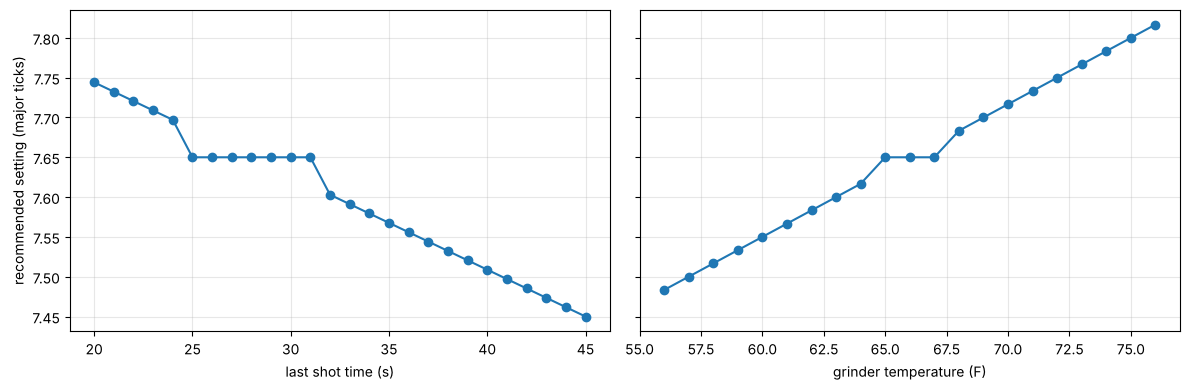

In [3]:
times = np.arange(20, 46)
temps = np.arange(56, 77)
last = dict(dose=IDEAL_DOSE, temp=IDEAL_TEMP, time=IDEAL_TIME, setting="7+6.5")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].plot(times, [recommend(**{**last, "time": t})["setting"] for t in times], "o-")
axes[0].set_xlabel("last shot time (s)")
axes[0].set_ylabel("recommended setting (major ticks)")
axes[1].plot(temps, [recommend(**{**last, "temp": T})["setting"] for T in temps], "o-")
axes[1].set_xlabel("grinder temperature (F)")
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()